In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor as GBR
from sklearn.metrics import mean_squared_error as mse, mean_absolute_error as mae
from sklearn.decomposition import PCA

In [3]:
import sys
import os

py_file_location = "/content"
sys.path.append(os.path.abspath(py_file_location))

In [4]:
from torch import nn
from src.training_models import *
from src.samplers import FastIFSampler, RandomSampler

In [5]:
df = pd.read_csv("/content/datasets/properties_2017.csv", low_memory=False)
missing_values = df.isnull().mean()

df = df.drop(missing_values[missing_values > .5].index, axis=1)

drop_cols = [
    'calculatedbathnbr', 'fullbathcnt', 'latitude', 'longitude',
    'propertycountylandusecode', 'censustractandblock',
    'unitcnt', 'taxvaluedollarcnt', 'structuretaxvaluedollarcnt', 'landtaxvaluedollarcnt', 'assessmentyear',
    'heatingorsystemtypeid', 'buildingqualitytypeid', 'propertyzoningdesc'
]
df = df.drop(columns=drop_cols)

fill_mode = [
    'regionidcity', 'regionidzip', 'fips', 'propertylandusetypeid',
    'rawcensustractandblock', 'regionidcounty'
]
fill_median = [
    'lotsizesquarefeet', 'finishedsquarefeet12', 'yearbuilt',
    'calculatedfinishedsquarefeet', 'taxamount', 'roomcnt',
    'bathroomcnt', 'bedroomcnt'
]

for col in fill_mode:
    df[col] = df[col].fillna(df[col].mode()[0])
for col in fill_median:
    df[col] = df[col].fillna(df[col].median())

In [6]:
df = pd.read_csv("/content/datasets/train_2017.csv", low_memory=False).merge(df, on="parcelid", how='left')
df["transactiondate"] = pd.to_datetime(df["transactiondate"])
df["transactiondate_year"] = df["transactiondate"].dt.year
df["transactiondate_month"] = df["transactiondate"].dt.month
df = df.drop(columns=["transactiondate", "parcelid"])

In [7]:
df = df.dropna(axis=0)

In [8]:
df.shape

(77613, 17)

In [9]:
target = "logerror"

df = df[
    (df[target] >= df[target].quantile(q=0.005)) & (df[target] <= df[target].quantile(q=0.995))
]

target_col = df.pop(target)

df = (df - df.min()) / (df.max() - df.min())
df = df.dropna(axis=1)
x_train, x_test, y_train, y_test = train_test_split(df, target_col, test_size=.2, random_state=42)

In [10]:
df.head()

,bathroomcnt,bedroomcnt,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,lotsizesquarefeet,propertylandusetypeid,rawcensustractandblock,regionidcity,regionidcounty,regionidzip,roomcnt,yearbuilt,taxamount,transactiondate_month
0,0.194444,0.2500,0.083690,0.136324,0.297297,0.000613,0.942623,0.297152,0.127409,0.000000,0.003280,0.000000,0.906250,0.018692,0.0
1,0.055556,0.1250,0.037649,0.061327,1.000000,0.001780,0.942623,0.999890,0.024423,0.426997,0.003678,0.333333,0.744792,0.009586,0.0
2,0.111111,0.1875,0.031398,0.051144,0.297297,0.001176,0.942623,0.296594,0.045593,0.000000,0.003609,0.400000,0.718750,0.010977,0.0
3,0.166667,0.2500,0.063303,0.103115,0.000000,0.001837,0.942623,0.002692,0.999987,1.000000,0.001146,0.000000,0.760417,0.002946,0.0
4,0.166667,0.1875,0.033341,0.054309,0.000000,0.039930,0.963115,0.000304,0.022785,1.000000,0.001544,0.000000,0.729167,0.002531,0.0


In [11]:
model = GBR(verbose=1, n_estimators=100, loss='absolute_error')
model.fit(x_train, y_train)
print(mse(model.predict(x_test), y_test), mae(model.predict(x_test), y_test))

      Iter       Train Loss   Remaining Time 
         1           0.0583           14.20s
         2           0.0582           14.01s
         3           0.0582           13.78s
         4           0.0581           13.73s
         5           0.0581           13.58s
         6           0.0581           13.46s
         7           0.0581           13.40s
         8           0.0580           13.20s
         9           0.0580           13.02s
        10           0.0580           12.87s
        20           0.0579           11.48s
        30           0.0578           10.32s
        40           0.0577            9.23s
        50           0.0577            7.89s
        60           0.0576            6.93s
        70           0.0576            5.67s
        80           0.0576            4.07s
        90           0.0575            2.10s
       100           0.0575            0.00s
0.009814175914298588 0.057682977195610476


In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [13]:
def show_graphics_loss(hist):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))
    ax1.plot(hist[0])
    ax1.set_title("loss function during training")
    ax1.set_xlabel("EPOCH")

    ax2.plot(hist[1])
    ax2.set_title("MAE validation loss")
    ax2.set_xlabel("EPOCH")

    plt.show()

In [14]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=15, out_features=64, device='cuda'),
            nn.Sigmoid(),
            nn.Linear(in_features=64, out_features=128, device='cuda'),
            nn.Sigmoid(),
            nn.Linear(in_features=128, out_features=512, device='cuda'),
            nn.Sigmoid(),
            nn.Linear(in_features=512, out_features=2048, device='cuda'),
            nn.Sigmoid(),
            nn.Linear(in_features=2048, out_features=512, device='cuda'),
            nn.Sigmoid(),
            nn.Linear(in_features=512, out_features=128, device='cuda'),
            nn.Sigmoid(),
            nn.Linear(in_features=128, out_features=128, device='cuda'),
            nn.Sigmoid(),
            nn.Linear(in_features=128, out_features=128, device='cuda'),
            nn.Sigmoid(),
            nn.Linear(in_features=128, out_features=1, device='cuda'),
        )

    def forward(self, x):
        logits = self.net(x)
        return logits

Epoch: 10, Batch: 720, Loss: 43.45: 100%|██████████| 7210/7210 [00:37<00:00, 191.72it/s]


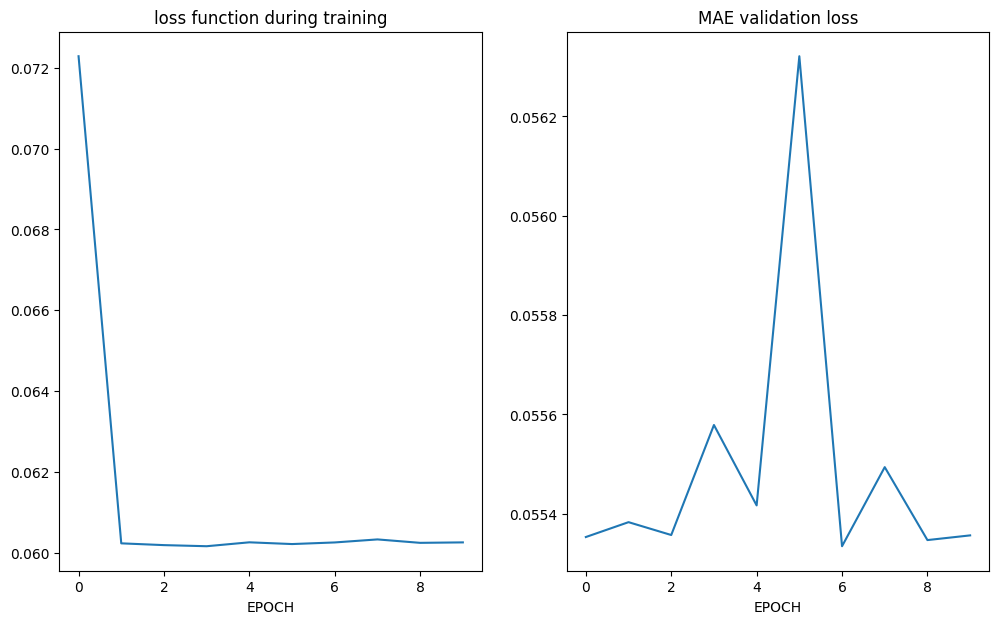

In [15]:
EPOCHS = 10
BATCH_SIZE = 64
LR = 0.01
loss_function = nn.L1Loss()

dataset_size = len(df)

x_train, x_eval, x_test = torch.split(torch.tensor(df.values).reshape([len(df), len(df.columns)]).float().cuda(), tuple(
    map(int, [dataset_size * .6, dataset_size * .2, dataset_size * .2])
))
y_train, y_eval, y_test = torch.split(torch.tensor(target_col.values).reshape([len(df), 1]).float().cuda(), tuple(
    map(int, [dataset_size * .6, dataset_size * .2, dataset_size * .2])
))

torch.manual_seed(42)
nn_model = Net()
train_dataloader = get_dataloader(x_train, y_train, batch_size=BATCH_SIZE, random=True)

res = train_nn(nn_model, train_dataloader, x_eval, y_eval, EPOCHS, LR, loss_function, device=device)
show_graphics_loss(res)

In [18]:
my_sampler = FastIFSampler(num_samples=4600, model=nn_model)
new_xy_train = my_sampler(
    x_train, y_train, torch.ones(y_train.shape).cuda(),
    x_eval=x_eval, y_eval=y_eval, num_examples_to_test=300, batch_size=256,
    use_knn=True, knn_k_value=5000
)

100%|██████████| 300/300 [1:58:17<00:00, 23.66s/it]


In [19]:
new_x_train, new_y_train, *_ = new_xy_train

In [21]:
new_train_dataloader = get_dataloader(new_x_train, new_y_train, batch_size=BATCH_SIZE, random=True)

torch.manual_seed(42)
nn_model2 = Net()
new_res = train_nn(nn_model2, new_train_dataloader, x_eval, y_eval, EPOCHS, LR, loss_function, device=device)


Epoch: 10, Batch: 71, Loss: 4.24: 100%|██████████| 720/720 [00:05<00:00, 125.33it/s]


In [24]:
hists = []
rnd_sampler = RandomSampler(4600)
for _ in range(10):
    torch.manual_seed(42)
    nn_model_rnd_sampler = Net()
    train_dataloader = get_dataloader(*rnd_sampler(x_train, y_train, torch.ones(y_train.shape))[:2], batch_size=BATCH_SIZE, random=True)

    hists.append(train_nn(nn_model_rnd_sampler, train_dataloader, x_eval, y_eval, EPOCHS, LR, loss_function))

res_rnd = np.array(hists).mean(axis=0)

Epoch: 10, Batch: 71, Loss: 4.36: 100%|██████████| 720/720 [00:04<00:00, 174.18it/s]


Text(0.5, 1.0, 'Training MAE loss')

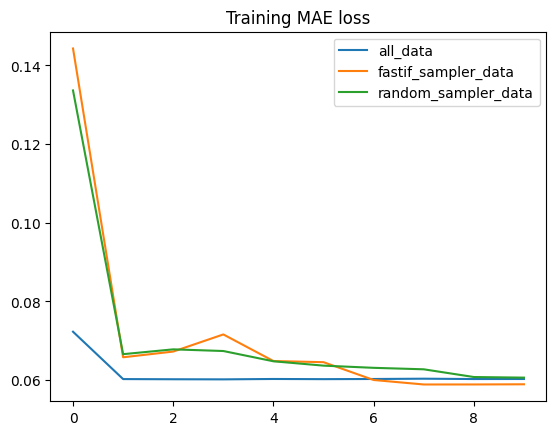

In [25]:
plt.plot(res[0], label='all_data')
plt.plot(new_res[0], label='fastif_sampler_data')
plt.plot(res_rnd[0], label='random_sampler_data')
plt.legend()
plt.title("Training MAE loss")

Text(0.5, 1.0, 'Validation MAE loss')

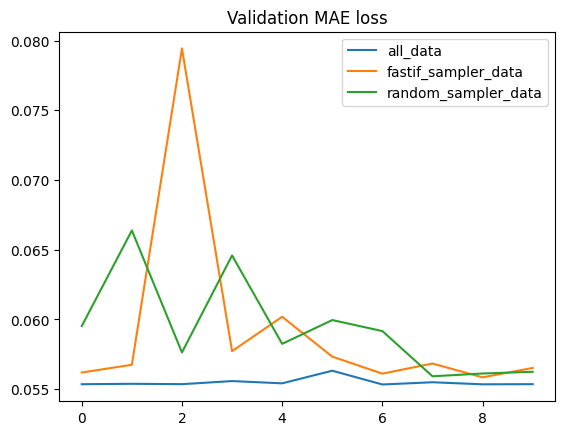

In [26]:
plt.plot(res[1], label='all_data')
plt.plot(new_res[1], label='fastif_sampler_data')
plt.plot(res_rnd[1], label='random_sampler_data')
plt.legend()
plt.title("Validation MAE loss")